In [3]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error

In [4]:
np.random.seed(101)
n_patients = 500


In [5]:
data = {
    'Patient_ID': range(5001, 5001 + n_patients),
    'Age': np.random.randint(18, 65, n_patients),
    'BMI': np.random.uniform(16, 40, n_patients).round(1),
    'Is_Smoker': np.random.choice([1, 0], n_patients, p=[0.2, 0.8]),
    'Children': np.random.randint(0, 5, n_patients),
   
    'Region': np.random.choice(['North', 'South', 'East', 'West', np.nan], n_patients, p=[0.23, 0.23, 0.24, 0.25, 0.05])
}

df_health = pd.DataFrame(data)


In [6]:
df_health['Region'] = df_health['Region'].fillna('Unknown')

In [7]:
df_health['Weight_Condition'] = np.where(df_health['BMI'] >= 30, 'Obese', 'Non-Obese')

In [8]:
df_health['Risk_Factor'] = (df_health['Age'] * 0.1) + (df_health['Is_Smoker'] * 5)

In [9]:
df_health['Medical_Charges'] = (df_health['Age'] * 250) + (df_health['Is_Smoker'] * 15000) + (df_health['BMI'] * 400) + noise
df_health['Medical_Charges'] = df_health['Medical_Charges'].round(2)

print(df_health.head())



NameError: name 'noise' is not defined

In [10]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error

np.random.seed(101)
n_patients = 500


In [11]:
data = {
    'Patient_ID': range(5001, 5001 + n_patients),
    'Age': np.random.randint(18, 65, n_patients),
    'BMI': np.random.uniform(16, 40, n_patients).round(1),
    'Is_Smoker': np.random.choice([1, 0], n_patients, p=[0.2, 0.8]),
    'Children': np.random.randint(0, 5, n_patients),
    'Region': np.random.choice(['North', 'South', 'East', 'West', np.nan], n_patients, p=[0.23, 0.23, 0.24, 0.25, 0.05])
}

df_health = pd.DataFrame(data)


In [12]:
df_health['Region'] = df_health['Region'].fillna('Unknown')

In [13]:
df_health['Weight_Condition'] = np.where(df_health['BMI'] >= 30, 'Obese', 'Non-Obese')

In [14]:
df_health['Risk_Factor'] = (df_health['Age'] * 0.1) + (df_health['Is_Smoker'] * 5)

In [15]:
noise = np.random.normal(500, 200, n_patients)

In [16]:
df_health['Medical_Charges'] = (df_health['Age'] * 250) + (df_health['Is_Smoker'] * 15000) + (df_health['BMI'] * 400) + noise

In [17]:
df_health['Medical_Charges'] = df_health['Medical_Charges'].round(2)

In [18]:
print("--- Cleaned Data Sample ---")
print(df_health.head())


--- Cleaned Data Sample ---
   Patient_ID  Age   BMI  Is_Smoker  Children Region Weight_Condition  \
0        5001   49  27.4          1         2  North        Non-Obese   
1        5002   29  38.9          1         2  South            Obese   
2        5003   35  31.7          0         0   East            Obese   
3        5004   24  21.1          0         2  South        Non-Obese   
4        5005   41  19.0          0         4  South        Non-Obese   

   Risk_Factor  Medical_Charges  
0          9.9         38567.95  
1          7.9         37833.59  
2          3.5         21765.98  
3          2.4         14890.05  
4          4.1         18704.91  


In [19]:
print("\n--- Summary Statistics ---")
print(df_health.describe())



--- Summary Statistics ---
        Patient_ID         Age         BMI   Is_Smoker   Children  \
count   500.000000  500.000000  500.000000  500.000000  500.00000   
mean   5250.500000   41.078000   28.331000    0.198000    1.92400   
std     144.481833   13.441028    7.075197    0.398891    1.38494   
min    5001.000000   18.000000   16.000000    0.000000    0.00000   
25%    5125.750000   29.000000   22.400000    0.000000    1.00000   
50%    5250.500000   41.000000   28.700000    0.000000    2.00000   
75%    5375.250000   52.250000   34.325000    0.000000    3.00000   
max    5500.000000   64.000000   40.000000    1.000000    4.00000   

       Risk_Factor  Medical_Charges  
count   500.000000       500.000000  
mean      5.097800     25073.878920  
std       2.389744      7503.352595  
min       1.800000     12402.360000  
25%       3.300000     19837.730000  
50%       4.700000     23708.285000  
75%       6.200000     28475.235000  
max      11.400000     47107.800000  


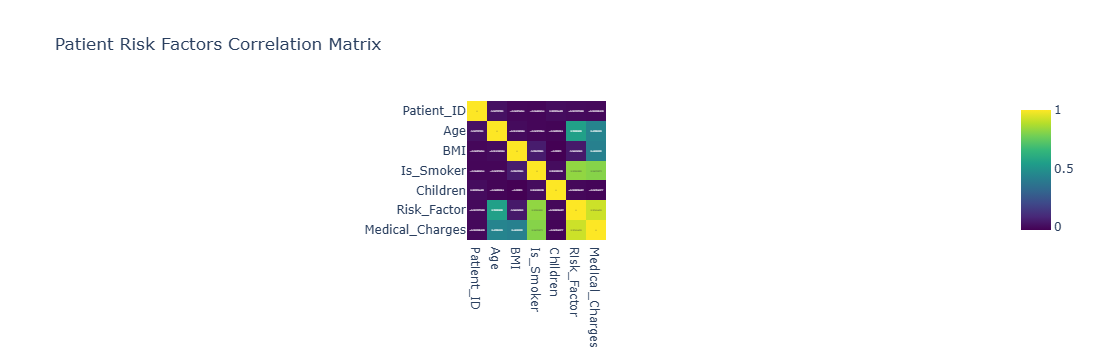

In [20]:
corr = df_health.select_dtypes(include=[np.number]).corr()

fig_corr = px.imshow(corr, text_auto=True, color_continuous_scale='Viridis',
                     title="Patient Risk Factors Correlation Matrix")
fig_corr.show()


In [23]:
expensive_cases = df_health.sort_values(by='Medical_Charges', ascending=False)

In [24]:
smokers_list = df_health[df_health['Age'] > 50]

In [25]:
sorted_by_region_bmi = df_health.sort_values(by=['Region', 'BMI'], ascending=[True, False])

In [26]:
high_risk_patients = df_health[df_health['Risk_Factor'] > 8]

In [27]:
i1 = df_health.loc[50:60, ['Age', 'BMI', 'Medical_Charges']]

In [28]:
i2 = df_health.loc[(df_health['Weight_Condition'] == 'Obese') & (df_health['Is_Smoker'] == 1)]

In [29]:
i3 = df_health.loc[df_health['Region'].isin(['North', 'South'])]

In [30]:
i4 = df_health.loc[df_health['Children'] == 0]

In [31]:
i5 = df_health.loc[df_health['Medical_Charges'] > df_health['Medical_Charges'].median()]

In [32]:
i6 = df_health.loc[df_health['Region'] != 'Unknown']

In [33]:
i7 = df_health.loc[df_health['Weight_Condition'].str.contains('Non')]

In [34]:
dash_fig = make_subplots(
    rows=3, cols=2,
    subplot_titles=("Charges Distribution by Region", "Age vs Medical Charges", 
                    "BMI Distribution Profile", "Smoking Impact on Healthcare Costs",
                    "Charges Breakdown by Dependents", "Risk Score vs Premium Charges"),
    specs=[[{"type": "xy"}, {"type": "xy"}],
           [{"type": "xy"}, {"type": "xy"}],
           [{"type": "xy"}, {"type": "xy"}]]
)


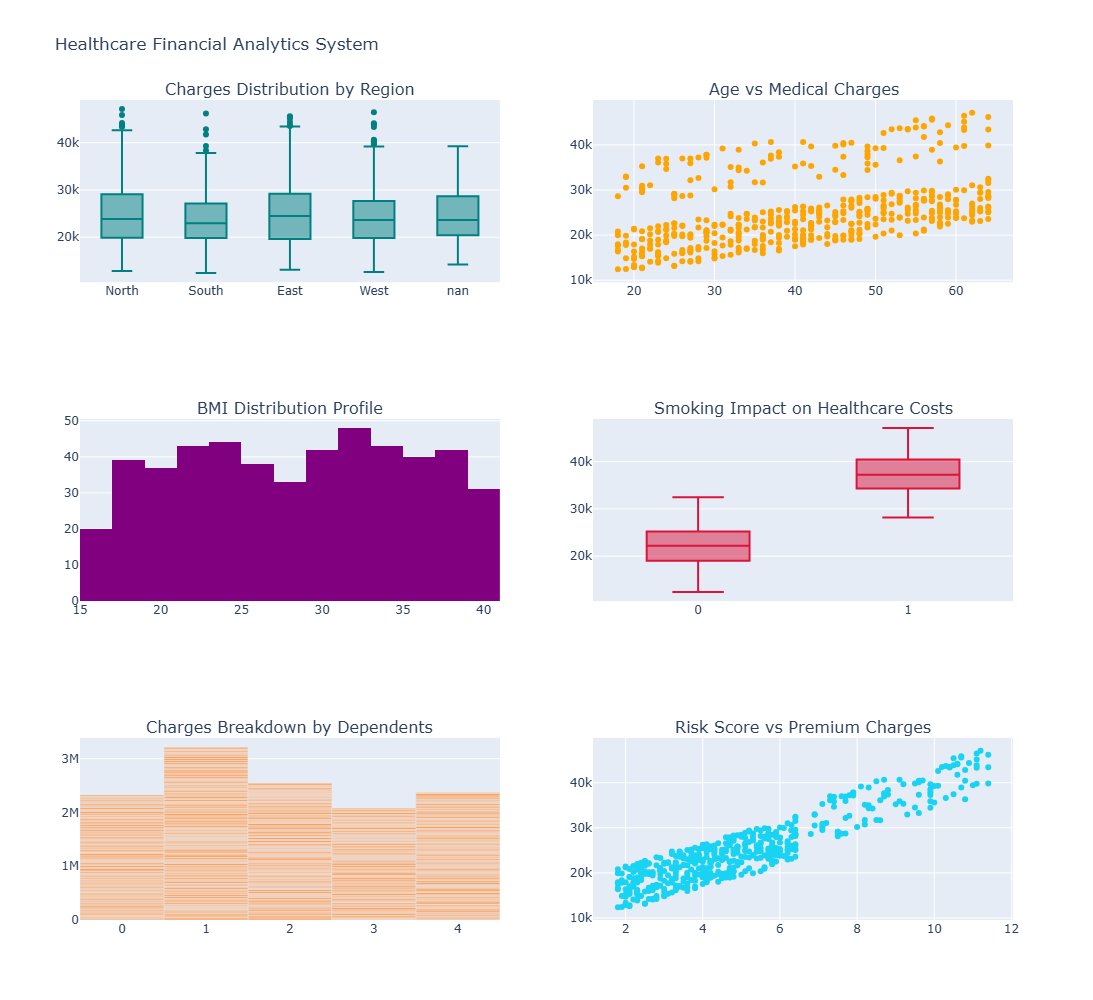

In [35]:
dash_fig.add_trace(go.Box(x=df_health['Region'], y=df_health['Medical_Charges'], marker_color='teal'), row=1, col=1)
dash_fig.add_trace(go.Scatter(x=df_health['Age'], y=df_health['Medical_Charges'], mode='markers', marker=dict(color='orange')), row=1, col=2)
dash_fig.add_trace(go.Histogram(x=df_health['BMI'], marker_color='purple'), row=2, col=1)
dash_fig.add_trace(go.Box(x=df_health['Is_Smoker'], y=df_health['Medical_Charges'], marker_color='crimson'), row=2, col=2)
dash_fig.add_trace(go.Bar(x=df_health['Children'], y=df_health['Medical_Charges']), row=3, col=1)
dash_fig.add_trace(go.Scatter(x=df_health['Risk_Factor'], y=df_health['Medical_Charges'], mode='markers'), row=3, col=2)

dash_fig.update_layout(height=1000, title_text="Healthcare Financial Analytics System", showlegend=False)
dash_fig.show()


In [36]:
X_reg = df_health[['Age', 'BMI', 'Is_Smoker', 'Children']]
y_reg = df_health['Medical_Charges']


In [37]:
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

In [38]:
scaler_r = StandardScaler()
X_train_scaled_r = scaler_r.fit_transform(X_train_r)
X_test_scaled_r = scaler_r.transform(X_test_r)


In [39]:
reg_model = LinearRegression()
reg_model.fit(X_train_scaled_r, y_train_r)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [40]:
predictions = reg_model.predict(X_test_scaled_r)

r2 = r2_score(y_test_r, predictions)
mae = mean_absolute_error(y_test_r, predictions)


In [41]:
print("\n--- Linear Regression Performance ---")
print(f"R² Score (Model Accuracy Variance Explained): {r2:.4f}")
print(f"Mean Absolute Error (Average Deviation): ${mae:.2f}")



--- Linear Regression Performance ---
R² Score (Model Accuracy Variance Explained): 0.9996
Mean Absolute Error (Average Deviation): $144.52
